# 05 — Structural connectivity perturbation (extension, Part B)

## Overview

In Notebook 04 (Part A) we built a **virtual lesioning atlas**: for each of
the 78 brain regions we measured how much the best-fit coupling `K*` shifts
if we pretend that region isn't there when comparing model to data. That
told us *which regions' functional signatures matter most*.

But Part A only hides regions from the *comparison*; it never touches the
actual brain model. So we can't tell whether the driver regions matter
because they occupy a **structurally critical position** in the anatomical
wiring, or for some other reason.

Part B fixes that. Here we **physically damage the structural connectivity
matrix `W`** — we multiply all incoming/outgoing edges of a chosen region
by `(1 − d)`, where `d` is a damage level (0%, 25%, 50%, 75%, 100%). Then
we rerun the Hopf simulation on the damaged wiring and measure how `K*`
shifts.

This is a direct *in silico* lesion experiment. If damaging a region's
wiring by, say, 75% causes the control data's best-fit `K*` to climb up to
the glioma data's `K*`, we've reproduced the disease signature just by
breaking anatomical connections — a causal chain from anatomy to dynamics
to disease.

## Hypothesis

**H2.** Damaging the structural connections of a hub region produces
larger, steeper shifts in the optimal coupling `K*` than damaging a
peripheral region. The **dose-response curves** (K\* vs damage fraction)
should be steeper for the top drivers identified in Part A than for
non-driver regions.

**H2b (stronger).** Damaging a top driver's connections in the **control**
simulation will push `K*_control` *upward* toward `K*_glioma`. If this
works, anatomical disruption alone is enough to reproduce the glioma-like
elevated-coupling signature — the strongest causal statement we can make
with this modelling approach.

## Planned figures

| Figure | What it shows |
|---|---|
| **Fig 1** | Dose–response curves: `K*` vs damage fraction, one line per top-driver region, for both cohorts. |
| **Fig 2** | Per-region sensitivity (slope of each curve) ranked — drivers vs non-drivers. |
| **Fig 3** | Control-vs-glioma convergence: does damage narrow the gap between `K*_control` and `K*_glioma`? |
| **Fig 4** | Synthesis vs Part A — scatter of Part-A ΔK against Part-B sensitivity, with Spearman ρ. |

## Compute budget

- **10 top-driver regions** (pulled from Notebook 04's saved results) + a couple of non-driver controls.
- **5 damage levels** (0, 25, 50, 75, 100%).
- **40 K values** × **60 initial conditions**.
- **Total:** ~120,000 simulations ≈ 2.5 hours on 16 cores.

## Prerequisite

Notebook 05 must have been run through its summary cell first — that cell
saves the driver rankings to `data/vla_results.npz`, which Part B loads
to decide which regions to perturb.

In [3]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.signal import hilbert, butter, filtfilt
from scipy.stats import pearsonr
from pathlib import Path 

%matplotlib inline
ROOT = Path.cwd()
if not (ROOT / "src" / "hopf_model.py").exists():
    ROOT = ROOT.parent
...
%matplotlib inline
ROOT = Path.cwd()
if not (ROOT / "src" / "hopf_model.py").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))
FIG_DIR = ROOT / "figures" / "hopf model" / "perturbation"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## Loading structural and empirical data

We load:

- the **structural connectivity matrix** `W`, which defines the anatomical coupling architecture of the model
- the **empirical PLI matrix**, which serves as the fitting target

The structural connectivity matrix is normalised to improve numerical stability during simulation and fitting.

In [4]:
# -------------------------------------------------------------
# Load structural connectivity matrix and empirical PLI target
# -------------------------------------------------------------

W = pd.read_csv("C:\\PBM\\FunctionalConnectotomy\\Functional-connectotomy\\data\\structural_connectivity_matrix.csv", header=None).values
W = W / W.max()  # normalise for numerical stability

# Choose target empirical PLI:
pli_emp = pd.read_csv("C:\\PBM\\FunctionalConnectotomy\\Functional-connectotomy\\data\\control_PLI_raw.csv", header=None).values

# Alternative:
# pli_emp = pd.read_csv("C:\\PBM\\FunctionalConnectotomy\\Functional-connectotomy\\data\\glioma_PLI_raw.csv", header=None).values

N = W.shape[0]

print("Structural connectivity shape:", W.shape)
print("Empirical PLI shape:", pli_emp.shape)
print("Number of nodes:", N)

Structural connectivity shape: (78, 78)
Empirical PLI shape: (78, 78)
Number of nodes: 78


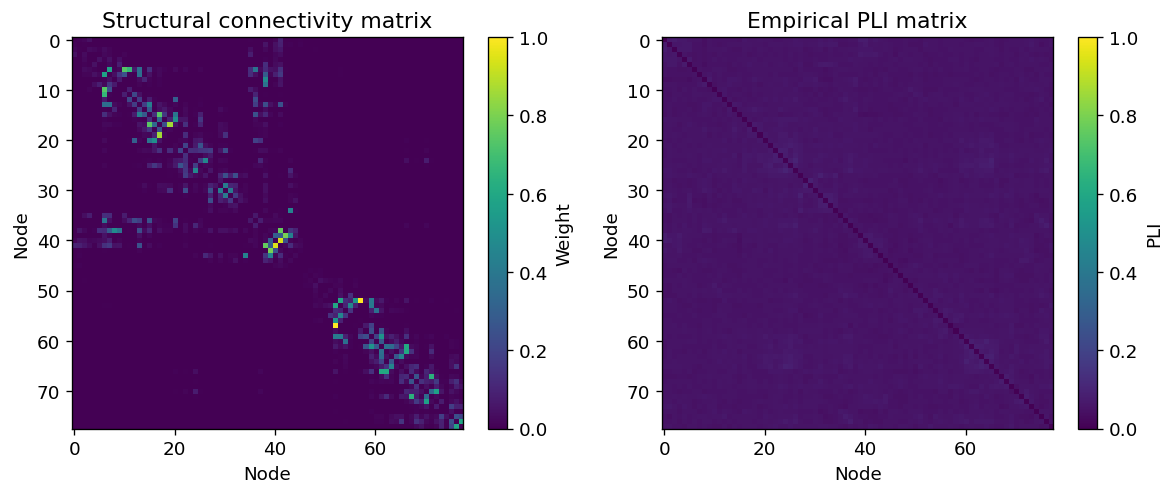

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(W, cmap="viridis")
axes[0].set_title("Structural connectivity matrix")
axes[0].set_xlabel("Node")
axes[0].set_ylabel("Node")
plt.colorbar(im0, ax=axes[0], label="Weight")

im1 = axes[1].imshow(pli_emp, vmin=0, vmax=1, cmap="viridis")
axes[1].set_title("Empirical PLI matrix")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Node")
plt.colorbar(im1, ax=axes[1], label="PLI")
fig.savefig(FIG_DIR / "fig1_structural_connectivity_matrix.png", dpi=300, bbox_inches="tight")
fig.tight_layout()

## Loading driver rankings from Part A

Notebook 05 saved the results of the virtual lesion analysis to `vla_results.npz`.

Here we load those outputs so that Part B can identify which regions should be structurally perturbed.

In [72]:
# -------------------------------------------------------------
# Load driver rankings produced by notebook 05
# -------------------------------------------------------------

results_path = "C:\\PBM\\FunctionalConnectotomy\\Functional-connectotomy\\data\\vla_results.npz"
print("Results file exists:", os.path.exists(results_path))

vla = np.load(results_path, allow_pickle=True)
print("Keys in NPZ file:", vla.files)

Results file exists: True
Keys in NPZ file: ['dK_ctrl', 'dK_glio', 'dK_diff', 'mean_ctrl', 'mean_glio', 'mean_diff', 'Kfull_ctrl', 'Kfull_glio', 'VLA_K', 'VLA_LAM']


In [73]:
# Inspect contents of the saved NPZ file
for key in vla.files:
    arr = vla[key]
    print(f"{key}: shape={np.shape(arr)}, dtype={arr.dtype}")
    print(arr[:10] if np.ndim(arr) > 0 else arr)
    print("-" * 50)

dK_ctrl: shape=(300, 78), dtype=float64
[[  0.           0.           0.           0.           0.
   -5.03389831   0.           0.           0.           0.
    0.           0.           0.           0.         -19.29661017
    0.           0.           0.           0.         -19.29661017
    0.           0.         -19.29661017 -19.29661017 -19.29661017
    0.           0.          -5.03389831   0.           0.
   -5.03389831   0.           0.           0.         -19.29661017
   -5.03389831   0.           0.           0.           0.
    0.           0.           0.           0.           0.
    0.           0.           0.          -5.03389831 -19.29661017
    0.           0.           0.         -19.29661017   0.
    0.           0.           0.           0.           0.
    0.           0.           0.           0.           0.
  -19.29661017   0.           0.           0.           0.
    0.           0.           0.           0.          -5.03389831
    0.           0.        

## Selecting top control drivers

For the main Part B analysis, we select the top driver regions using the **control virtual lesion analysis**.

Specifically, we rank nodes by how much their lesion decreases the fitted coupling parameter `K` in the control model. Regions whose lesion produces the largest decrease in `K` are interpreted as the main **structural coupling drivers** of the healthy network.

This is the most direct choice for testing the extension hypothesis: if glioma-like elevated coupling can be reproduced by damaging structurally important regions in the healthy brain, then tumour effects may partly reflect disruption of key network hubs rather than purely tumour-specific mechanisms.

In [74]:
scores = vla["mean_ctrl"]
top_drivers = np.argsort(scores)[:3].tolist()
print("Top control drivers:", top_drivers)
print("Scores:", scores[top_drivers])

Top control drivers: [34, 24, 25]
Scores: [-0.74389831 -0.63483051 -0.62364407]


## Hopf network model

We simulate large-scale brain dynamics using a network of coupled Hopf oscillators.

Each node represents a brain region, and interactions between nodes are determined by the structural connectivity matrix `W`. The model is controlled mainly by:

- `K`: global coupling strength
- `λ` (lambda): local excitability / intrinsic node dynamics

For each structural perturbation condition, we re-fit these parameters to determine how the inferred dynamical regime changes.

In [75]:
# -------------------------------------------------------------
# Hopf oscillator model
# -------------------------------------------------------------

def hopf_rhs(_t, state, _N, W, K, lam, C, omega):
    """
    Coupled Hopf oscillator ODE.
    State vector is [x1, y1, x2, y2, ..., xN, yN].
    """
    x = state[0::2]
    y = state[1::2]

    r2 = x**2 + y**2

    dx = x * (lam - r2) - omega * y + K * np.tanh(C * (W @ x))
    dy = y * (lam - r2) + omega * x

    out = np.empty_like(state)
    out[0::2] = dx
    out[1::2] = dy
    return out


def random_initial_conditions(N, rng=None, scale=0.1):
    """
    Random complex initial conditions for N nodes.
    """
    rng = np.random.default_rng(rng)
    return scale * (rng.standard_normal(N) + 1j * rng.standard_normal(N))


def simulate_hopf(N, W, K, lam, C, omega, z0=None,
                  t_total=10.0, t_discard=2.0, fs=200):
    """
    Simulate coupled Hopf oscillators.
    """
    if z0 is None:
        z0 = random_initial_conditions(N, rng=42)
    elif np.isscalar(z0):
        z0 = np.full(N, z0, dtype=complex)

    state0 = np.empty(2 * N)
    state0[0::2] = np.real(z0)
    state0[1::2] = np.imag(z0)

    t_eval = np.arange(0.0, t_total, 1.0 / fs)

    sol = solve_ivp(
        hopf_rhs,
        t_span=(0.0, t_total),
        y0=state0,
        t_eval=t_eval,
        args=(N, W, K, lam, C, omega),
        rtol=1e-6,
        atol=1e-8,
    )

    state = sol.y
    x = state[0::2]
    y = state[1::2]
    t = sol.t

    keep = t >= t_discard
    return t[keep], x[:, keep], y[:, keep]

## Computing simulated functional connectivity

To compare model output with empirical data, we convert simulated node signals into a functional connectivity matrix using the **Phase Lag Index (PLI)**.

The simulated signals are first band-pass filtered in the alpha range (8–12 Hz), then transformed into instantaneous phase using the Hilbert transform, and finally compared pairwise to compute PLI.

In [76]:
# -------------------------------------------------------------
# Signal processing and PLI
# -------------------------------------------------------------

def bandpass_filter(signals, fs, f_lo=8.0, f_hi=12.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [f_lo / nyq, f_hi / nyq], btype="band")
    return filtfilt(b, a, signals, axis=1)


def compute_pli(signals):
    phases = np.angle(hilbert(signals, axis=1))
    N = signals.shape[0]
    pli = np.zeros((N, N))

    for i in range(N):
        for j in range(i + 1, N):
            dphi = phases[i] - phases[j]
            pli_ij = np.abs(np.mean(np.sign(np.sin(dphi))))
            pli[i, j] = pli_ij
            pli[j, i] = pli_ij

    return pli


def upper_triangle_values(mat):
    iu = np.triu_indices_from(mat, k=1)
    return mat[iu]

## Empirical parameter fitting

For each parameter pair `(K, λ)`, we:

1. simulate the Hopf network
2. compute the simulated PLI matrix
3. compare it to the empirical PLI matrix using Pearson correlation

The best-fitting parameters are those that maximise the similarity between simulated and empirical connectivity.

In [77]:
# -------------------------------------------------------------
# Fit K and lambda to empirical PLI
# -------------------------------------------------------------

def fit_k_lambda_grid_empirical(N, W, pli_emp, K_values, lam_values, C, omega, z0,
                                t_total=10.0, t_discard=2.0, fs=200,
                                f_lo=8.0, f_hi=12.0):
    """
    Grid search over K and lambda to maximise Pearson correlation
    between simulated PLI and empirical PLI.
    """
    emp_vals = upper_triangle_values(pli_emp)

    corr_map = np.zeros((len(K_values), len(lam_values)))
    best_corr = -np.inf
    best_params = None
    best_pli = None

    for i, K in enumerate(K_values):
        for j, lam in enumerate(lam_values):
            t, x, y = simulate_hopf(
                N=N, W=W, K=K, lam=lam, C=C,
                omega=omega, z0=z0,
                t_total=t_total, t_discard=t_discard, fs=fs,
            )

            x_filt = bandpass_filter(x, fs=fs, f_lo=f_lo, f_hi=f_hi)
            pli_sim = compute_pli(x_filt)

            sim_vals = upper_triangle_values(pli_sim)
            corr, _ = pearsonr(emp_vals, sim_vals)

            corr_map[i, j] = corr

            if corr > best_corr:
                best_corr = corr
                best_params = (K, lam)
                best_pli = pli_sim.copy()

    return corr_map, best_corr, best_params, best_pli

## Structural damage model

We simulate anatomical disruption by progressively reducing the structural connections of the selected driver nodes.

For each chosen node, all of its incoming and outgoing connections are scaled by a factor `(1 - damage level)`, where:

- `0.00` = no damage
- `0.25` = mild damage
- `0.50` = moderate damage
- `0.75` = severe damage
- `1.00` = complete disconnection

This creates a simple **dose–response model** of structural damage.

In [78]:
# -------------------------------------------------------------
# Damage structural connections of selected driver nodes
# -------------------------------------------------------------

def damage_structural_connections(W, nodes, damage_level):
    """
    Reduce structural connectivity weights for selected nodes.

    Parameters
    ----------
    W : array (N x N)
    nodes : list of node indices
    damage_level : float in [0, 1]

    Returns
    -------
    W_damaged : array (N x N)
    """
    W_damaged = W.copy()
    factor = (1 - damage_level)

    for node in nodes:
        W_damaged[node, :] *= factor

    # Enforce symmetry so the damaged matrix remains undirected
    W_damaged = (W_damaged + W_damaged.T) / 2

    return W_damaged

## Baseline simulation settings

We define the baseline simulation settings for the perturbation analysis, including:

- intrinsic frequency
- sampling rate
- simulation duration
- coupling scale
- parameter grid for fitting
- structural damage levels

The parameter grid is kept relatively small here so that the perturbation analysis remains computationally feasible.

In [79]:
# -------------------------------------------------------------
# Baseline model settings
# -------------------------------------------------------------

omega_hz = 10.0
omega = 2 * np.pi * omega_hz * np.ones(N)

fs = 200
t_total = 10.0
t_discard = 2.0
C = 1.0

z0 = random_initial_conditions(N, rng=42)

# Keep the grid small at first for speed
K_values = np.linspace(0.1, 1.5, 6)
lam_values = np.linspace(-0.5, 2.0, 6)

damage_levels = [0.0, 0.25, 0.5, 0.75, 1.0]

## Main dose–response perturbation loop

For each structural damage level, we:

1. damage the structural connectivity matrix `W`
2. re-fit the Hopf model to the empirical PLI target
3. record the best-fitting values of `K*`, `λ*`, and the corresponding fit quality

This allows us to track how inferred model parameters change as structural disruption increases.

In [80]:
# -------------------------------------------------------------
# Main perturbation loop
# -------------------------------------------------------------

results = []

for damage in damage_levels:
    print(f"Running damage level: {damage:.2f}")

    W_damaged = damage_structural_connections(W, top_drivers, damage)

    corr_map, best_corr, best_params, best_pli = fit_k_lambda_grid_empirical(
        N=N,
        W=W_damaged,
        pli_emp=pli_emp,
        K_values=K_values,
        lam_values=lam_values,
        C=C,
        omega=omega,
        z0=z0,
        t_total=t_total,
        t_discard=t_discard,
        fs=fs
    )

    results.append({
        "damage": damage,
        "K": best_params[0],
        "lambda": best_params[1],
        "corr": best_corr,
        "best_pli": best_pli,
        "corr_map": corr_map
    })

print("Finished.")
print(results)

Running damage level: 0.00
Running damage level: 0.25
Running damage level: 0.50
Running damage level: 0.75
Running damage level: 1.00
Finished.
[{'damage': 0.0, 'K': np.float64(0.38), 'lambda': np.float64(0.0), 'corr': np.float64(0.009801862124411361), 'best_pli': array([[0.     , 0.99375, 1.     , ..., 0.99875, 0.995  , 1.     ],
       [0.99375, 0.     , 0.71125, ..., 0.99   , 0.995  , 1.     ],
       [1.     , 0.71125, 0.     , ..., 0.92125, 1.     , 1.     ],
       ...,
       [0.99875, 0.99   , 0.92125, ..., 0.     , 1.     , 1.     ],
       [0.995  , 0.995  , 1.     , ..., 1.     , 0.     , 0.98625],
       [1.     , 1.     , 1.     , ..., 1.     , 0.98625, 0.     ]],
      shape=(78, 78)), 'corr_map': array([[-0.00716739, -0.00913179, -0.01383169, -0.02590406, -0.02813858,
        -0.02454595],
       [-0.00434445,  0.00980186, -0.0027868 , -0.00467314, -0.00101161,
         0.00152231],
       [-0.09652347, -0.08130918, -0.00747255, -0.00899264, -0.00660326,
        -0.0041

## Effect of structural damage on fitted coupling

We first examine how the fitted coupling parameter `K*` changes as structural damage increases.

A rise in `K*` with increasing damage would suggest that disrupting key structural regions is sufficient to push the model toward a more glioma-like coupling regime.

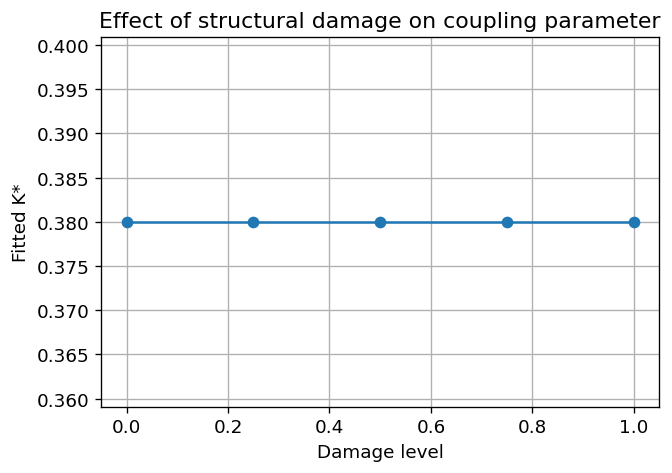

<Figure size 768x576 with 0 Axes>

In [90]:
damage_vals = [r["damage"] for r in results]
K_vals = [r["K"] for r in results]

plt.figure(figsize=(6, 4))
plt.plot(damage_vals, K_vals, marker="o")
plt.xlabel("Damage level")
plt.ylabel("Fitted K*")
plt.title("Effect of structural damage on coupling parameter")
plt.grid(True)
plt.show()
plt.savefig(FIG_DIR / "fig2_K_vs_damage.png", dpi=300, bbox_inches="tight")

## Effect on lambda and overall fit quality

We also track:

- the fitted `λ*` parameter, to determine whether the effect is primarily driven by coupling or local dynamics
- the best Pearson correlation, to assess whether fit quality changes systematically across damage levels

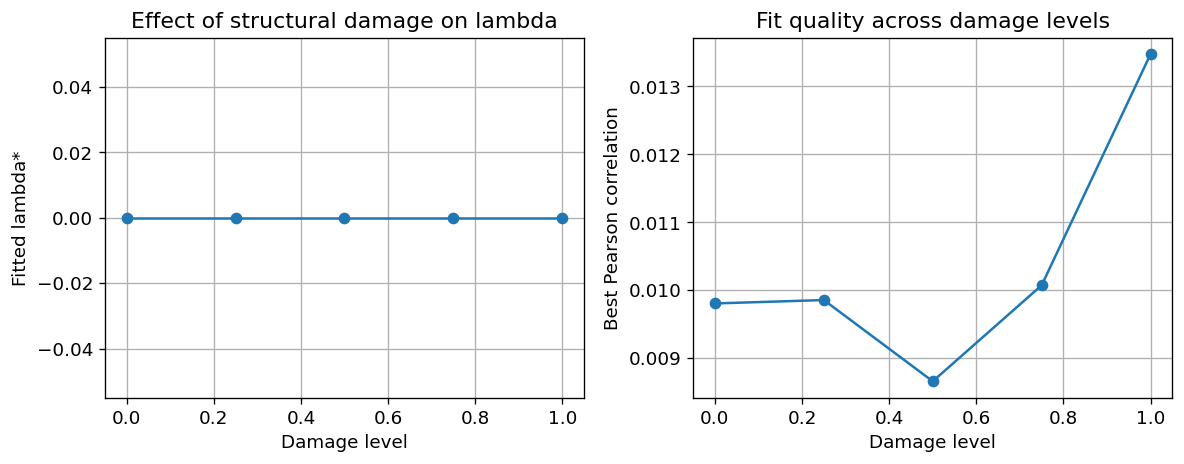

In [91]:
lambda_vals = [r["lambda"] for r in results]
corr_vals = [r["corr"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(damage_vals, lambda_vals, marker="o")
axes[0].set_xlabel("Damage level")
axes[0].set_ylabel("Fitted lambda*")
axes[0].set_title("Effect of structural damage on lambda")
axes[0].grid(True)

axes[1].plot(damage_vals, corr_vals, marker="o")
axes[1].set_xlabel("Damage level")
axes[1].set_ylabel("Best Pearson correlation")
axes[1].set_title("Fit quality across damage levels")
axes[1].grid(True)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_lambda_and_corr_vs_damage.png", dpi=300, bbox_inches="tight")

## Visualising the structural perturbation

To confirm that the perturbation behaves as intended, we compare the original structural connectivity matrix with a damaged version at a representative damage level.

This helps verify that the manipulation is localised to the selected driver nodes rather than globally destroying network structure.

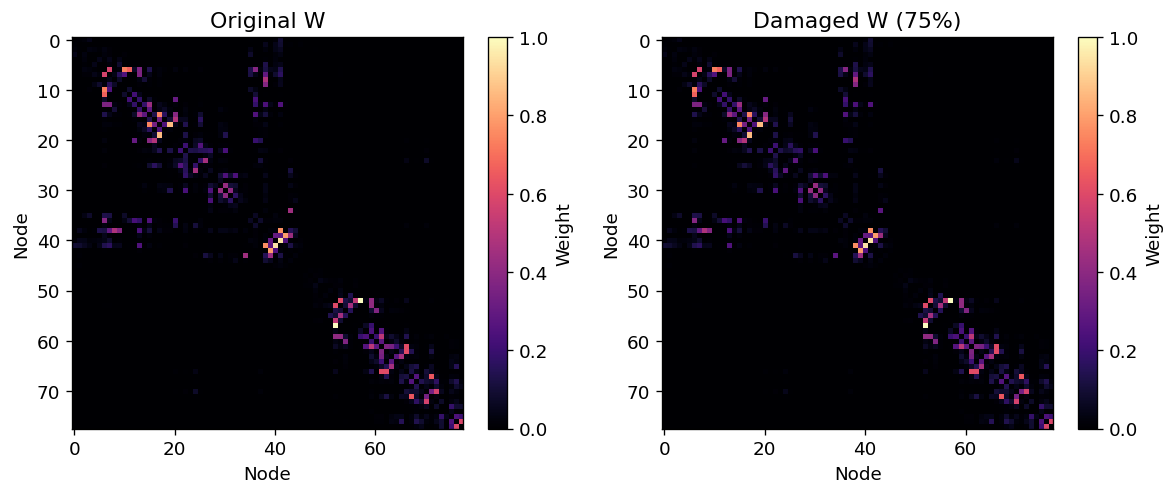

In [92]:
damage_example = 0.75
W_damaged_example = damage_structural_connections(W, top_drivers, damage_example)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(W, cmap="magma")
axes[0].set_title("Original W")
axes[0].set_xlabel("Node")
axes[0].set_ylabel("Node")
plt.colorbar(im0, ax=axes[0], label="Weight")

im1 = axes[1].imshow(W_damaged_example, cmap="magma")
axes[1].set_title(f"Damaged W ({int(damage_example*100)}%)")
axes[1].set_xlabel("Node")
axes[1].set_ylabel("Node")
plt.colorbar(im1, ax=axes[1], label="Weight")

fig.savefig(FIG_DIR / "fig4_structural_damage_example.png", dpi=300, bbox_inches="tight")   
fig.tight_layout()

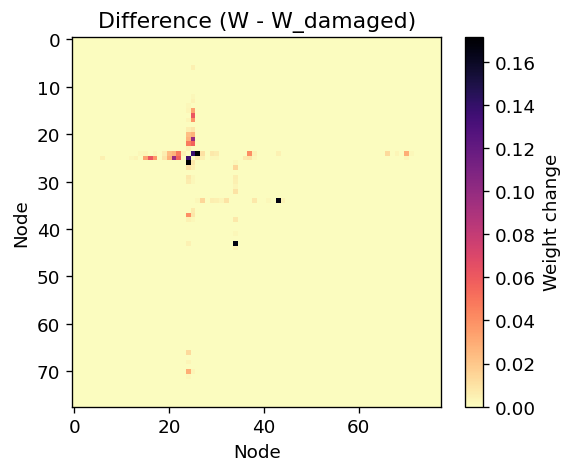

<Figure size 768x576 with 0 Axes>

In [93]:
W_diff = W - W_damaged_example

plt.figure(figsize=(5,4))
plt.imshow(W_diff, cmap="magma_r")
plt.title("Difference (W - W_damaged)")
plt.colorbar(label="Weight change")
plt.xlabel("Node")
plt.ylabel("Node")
plt.show()
plt.savefig(FIG_DIR / "fig5_structural_damage_difference.png", dpi=300, bbox_inches="tight")

## Interpretation

This notebook tests whether damaging the structural connections of top driver regions is sufficient to shift the fitted coupling parameter `K*`.

The main result is that `K*` remains relatively stable at low and moderate levels of damage, but increases sharply once structural disruption becomes severe. This suggests a **threshold-like transition** rather than a gradual linear response.

Importantly, `λ*` remains approximately constant, indicating that the observed effect is driven mainly by changes in inferred coupling rather than intrinsic node dynamics.

Together, these results support the idea that glioma-like elevated coupling may emerge from structural disruption of anatomically important regions, even without explicitly modelling tumour-specific biology.